In [4]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,SystemMessage

from extract import extract_text_pdf,extract_relevant_snippets
from schema import ContratOutput,State
from pydantic import ValidationError

from langgraph.graph import START,END,StateGraph

import os
from dotenv import load_dotenv



load_dotenv()
llm = ChatGroq(
        api_key=os.getenv("myfirstApiKey"),
        model="qwen/qwen3-32b",
        temperature=0.1,
    ).with_structured_output(ContratOutput)

sys_mess = """
Tu va recevoir du texte contenant les informations issus d'un contrat, ta mission sera d'extraire les informations suivantes:
 - periode: la période de travaille exemple 18/02/2025 - 25/02/2025
 - heures: Heures de travail exemple 15h-19h
 - remuneration: Remuneration du travail correspondant à ce qu'il obtient par heure de travail
 - commentaire: Si tu estimes qu'il faut mettre des commentaire, sinon tu met None


"""


def extraction(state:State):
    pdf_path = state["messages"]
    text_raw = extract_text_pdf(pdf_path=pdf_path)
    text = extract_relevant_snippets(text=text_raw)

    return {"retrieved_text":text}



def llm_response(state:State):
    text = state["retrieved_text"]

    msg = llm.invoke([
            SystemMessage(content=sys_mess),
            HumanMessage(content= f"Voici le texte extrait du contrat: {text}")
        ])
    
    return {"messages":state["messages"]+msg}


def output_validation(state:State):
    
    llm_text = state["messages"][-1].content

    try:
        final_output = ContratOutput.model_validate(llm_text).model_dump()
        print("It's okay")
    except ValidationError as ve:
        print(f"Erreur lors de la validation pydantic: {ve}")
    
    return {"final_output":final_output}





graph=StateGraph(State)

graph.add_node("extractor",extraction)
graph.add_node("llm",llm_response)
graph.add_node("validator",output_validation)

graph.add_edge(START,"extractor")
graph.add_edge("extractor","llm")
graph.add_edge("llm","validator")
graph.add_edge("validator",END)

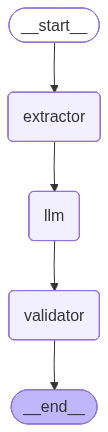

In [6]:
graph.compile()